# Monte Carlo Integration and Random Walks

Monte Carlo quadrature and error scaling, continuous two-dimensional random walks, and self-avoiding walks.

Computational physics coursework by Udayan Sharma. Original code comments and saved outputs are retained. See the repository README for execution notes.


Integral of sqrt(4-x^2) from 0 to 2
Estimate of pi  = 3.14222056
Exact pi        = 3.14159265
Std dev         = 0.00865887
Std error (SEM) = 0.00061227
Absolute error  = 0.00062791

Estimating pi to 3, 4, and 5 significant digits:

         n    Ntrials           mean      abs error            SEM
      1000        100     3.14179037     0.00019772     0.00256269
     10000        100     3.14292659     0.00133394     0.00083961
    100000        100     3.14234364     0.00075099     0.00027139

Error scaling study for integral of sqrt(4-x^2) from 0 to 2:

       n  Ntrials      N_total           mean            err
      10      200         2000     3.13577406     0.01922384
      30      200         6000     3.14444248     0.01224170
     100      200        20000     3.14009504     0.00683864
     300      200        60000     3.13998306     0.00383235
    1000      200       200000     3.14164663     0.00207432
    3000      200       600000     3.14280824     0.00114248
   10000  

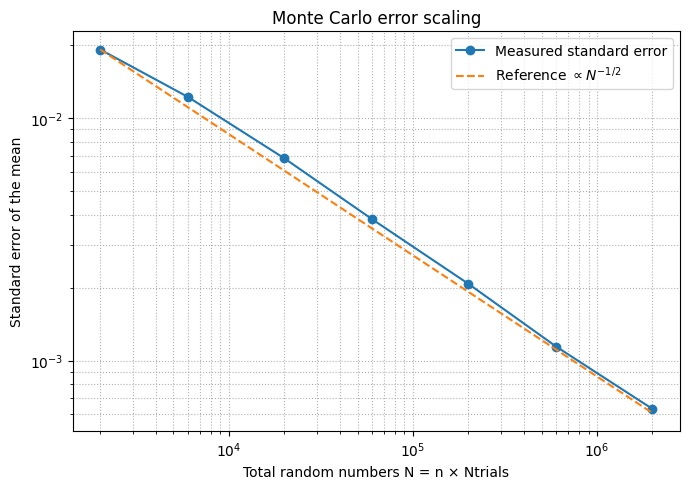


Integral of 1/sqrt(4-x^2) from -2 to 2
Estimate        = 3.14159265
Exact value     = 3.14159265
Std dev         = 0.00000000
Std error (SEM) = 0.00000000
Absolute error  = 0.00000000

Integral of e^(-x) * ln(x) from 0 to infinity
Estimate        = -0.57783278
Exact value     = -0.57721566
Std dev         = 0.01346195
Std error (SEM) = 0.00095190
Absolute error  = 0.00061712


In [ ]:

import random;
import math;
import numpy as np;
import matplotlib.pyplot as plt;

# MC helper: uniform sampling on [a,b], repeated over Ntrials & return mean over trials, std dev over trials, standard error
def mc_uniform_integral(func, a, b, n, Ntrials):
    results = [];

    for _ in range(Ntrials):
        total = 0.0;
        for _ in range(n):
            x = a + random.random() * (b - a);
            total += func(x);
        estimate = (b - a) * total / n;
        results.append(estimate);

    results = np.array(results);
    mean = np.mean(results);
    stddev = np.std(results, ddof = 0);
    err = stddev / math.sqrt(Ntrials);
    return mean, stddev, err;


# Integral of sqrt(4 - x^2) from 0 to 2 = pi
def f_pi(x):
    return math.sqrt(4.0 - x * x);


# Integral of 1 / sqrt(4-x^2) from -2 to 2 using x = 2 sin(theta), theta in [-pi/2, pi/2]
def mc_integral_singular(n, Ntrials):
    results = [];

    for _ in range(Ntrials):
        total = 0.0;
        for _ in range(n):
            theta = -math.pi / 2 + random.random() * math.pi;
            # transformed integrand is just 1
            total += 1.0;
        estimate = math.pi * total / n;
        results.append(estimate);

    results = np.array(results);
    mean = np.mean(results);
    stddev = np.std(results, ddof = 0);
    err = stddev / math.sqrt(Ntrials);
    return mean, stddev, err;


# Integral of e^(-x) * ln(x) from 0 to ∞
def mc_integral_exp_log(n, Ntrials):
    results = [];

    for _ in range(Ntrials):
        total = 0.0;
        for _ in range(n):
            u = random.random();
            # avoid u = 0 exactly, though random.random() is in [0,1)
            while u == 0.0:
                u = random.random();
            x = -math.log(u);
            total += math.log(x);
        estimate = total / n;
        results.append(estimate);

    results = np.array(results);
    mean = np.mean(results);
    stddev = np.std(results, ddof = 0);
    err = stddev / math.sqrt(Ntrials);
    return mean, stddev, err;


# Error scaling study for pi integral -> N_total = n * Ntrials
def error_scaling_study():
    n_values = [10, 30, 100, 300, 1000, 3000, 10000];
    Ntrials = 200;
    N_total_list = [];
    err_list = [];
    mean_list = [];

    print("\nError scaling study for integral of sqrt(4-x^2) from 0 to 2:\n");
    print(f"{'n':>8} {'Ntrials':>8} {'N_total':>12} {'mean':>14} {'err':>14}");

    for n in n_values:
        mean, stddev, err = mc_uniform_integral(f_pi, 0.0, 2.0, n, Ntrials);
        N_total = n * Ntrials;

        N_total_list.append(N_total);
        err_list.append(err);
        mean_list.append(mean);

        print(f"{n:8d} {Ntrials:8d} {N_total:12d} {mean:14.8f} {err:14.8f}");

    # log-log plot of error vs total random numbers
    plt.figure(figsize = (7, 5));
    plt.loglog(N_total_list, err_list, 'o-', label = 'Measured standard error');

    # reference N^{-1/2} line, scaled to first point
    N0 = N_total_list[0];
    e0 = err_list[0];
    ref = [e0 * math.sqrt(N0 / N) for N in N_total_list];
    plt.loglog(N_total_list, ref, '--', label = r'Reference $\propto N^{-1/2}$');

    plt.xlabel('Total random numbers N = n × Ntrials');
    plt.ylabel('Standard error of the mean');
    plt.title('Monte Carlo error scaling');
    plt.legend();
    plt.grid(True, which = 'both', ls = ':');
    plt.tight_layout();
    plt.show();


def significant_digits_report():
    exact_pi = math.pi;
    print("\nEstimating pi to 3, 4, and 5 significant digits:\n");
    test_cases = [(1000, 100), (10000, 100), (100000, 100)];

    print(f"{'n':>10} {'Ntrials':>10} {'mean':>14} {'abs error':>14} {'SEM':>14}");
    for n, Ntrials in test_cases:
        mean, stddev, err = mc_uniform_integral(f_pi, 0.0, 2.0, n, Ntrials);
        abs_error = abs(mean - exact_pi);
        print(f"{n:10d} {Ntrials:10d} {mean:14.8f} {abs_error:14.8f} {err:14.8f}");


def run_all():
    random.seed(580);

    # Integral of sqrt(4-x^2) from 0 to 2
    print("=" * 70);
    print("Integral of sqrt(4-x^2) from 0 to 2");
    print("=" * 70);
    mean, stddev, err = mc_uniform_integral(f_pi, 0.0, 2.0, n = 10000, Ntrials = 200);
    print(f"Estimate of pi  = {mean:.8f}");
    print(f"Exact pi        = {math.pi:.8f}");
    print(f"Std dev         = {stddev:.8f}");
    print(f"Std error (SEM) = {err:.8f}")
    print(f"Absolute error  = {abs(mean - math.pi):.8f}");

    significant_digits_report();
    error_scaling_study();

    # Integral of 1/sqrt(4-x^2) from -2 to 2
    print("\n" + "=" * 70);
    print("Integral of 1/sqrt(4-x^2) from -2 to 2");
    print("=" * 70);
    mean, stddev, err = mc_integral_singular(n = 10000, Ntrials = 200);
    print(f"Estimate        = {mean:.8f}");
    print(f"Exact value     = {math.pi:.8f}");
    print(f"Std dev         = {stddev:.8f}");
    print(f"Std error (SEM) = {err:.8f}");
    print(f"Absolute error  = {abs(mean - math.pi):.8f}");

    # Integral of e^(-x) * ln(x) from 0 to infinity
    print("\n" + "=" * 70);
    print("Integral of e^(-x) * ln(x) from 0 to infinity");
    print("=" * 70);
    exact = -math.euler_gamma if hasattr(math, "euler_gamma") else -0.5772156649015329;
    mean, stddev, err = mc_integral_exp_log(n = 10000, Ntrials = 200);
    print(f"Estimate        = {mean:.8f}");
    print(f"Exact value     = {exact:.8f}");
    print(f"Std dev         = {stddev:.8f}");
    print(f"Std error (SEM) = {err:.8f}");
    print(f"Absolute error  = {abs(mean - exact):.8f}");

if __name__ == "__main__":
    run_all();

# EOF


maximum number of steps: 1000
number of walks: 1000

Fit to log10(<r^2>) vs log10(n):
   log10(<r^2>) = 0.993924 * log10(n) + -0.462581
   slope uncertainty da = 0.000384

Average value of sigma(r^2)/<r^2> over n=1..Nsteps: 1.002567
Value at final step n=1000: sigma(r^2)/<r^2> = 1.044750


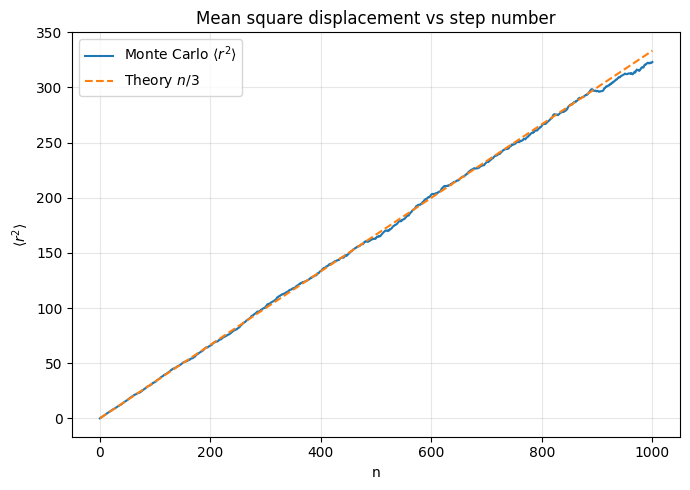

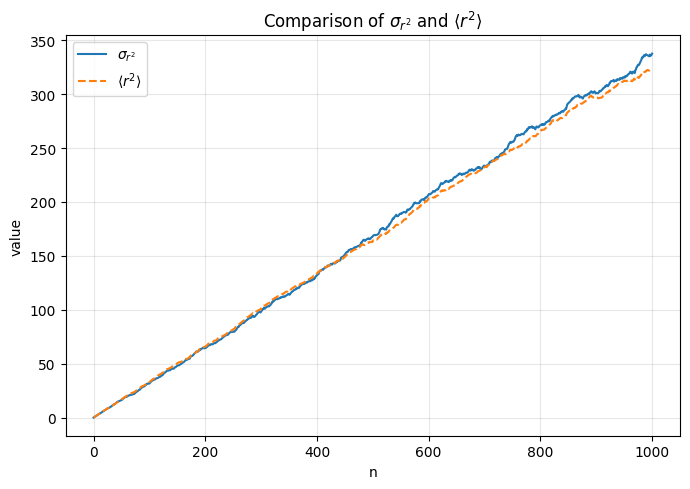

In [ ]:

import random;
import math;
import numpy as np;
import matplotlib.pyplot as plt;

# Generate ONE 2D continuous random walk -> random direction theta uniform in [0, 2pi) & random step length d uniform in (0,1)
def generate_walk_continuous(Nsteps):
    x = np.zeros((Nsteps + 1, 2), dtype = float);
    x[0] = [0.0, 0.0];

    for i in range(Nsteps):
        theta = 2.0 * math.pi * random.random();
        d = random.random();   # uniform on [0,1) as it's effectively 0 < d < 1 for MC
        dx = d * math.cos(theta);
        dy = d * math.sin(theta);
        x[i + 1] = x[i] + np.array([dx, dy]);

    return x;

# Running the progream now
Nsteps = int(input("maximum number of steps: "));
Nwalks = int(input("number of walks: "));
random.seed(580);

# storage for <r^2> and <(r^2)^2>
r2_sum = np.zeros(Nsteps + 1);
r4_sum = np.zeros(Nsteps + 1);

# optionally store a few walks for plotting
walks_to_plot = min(5, Nwalks);
stored_walks = [];

for j in range(Nwalks):
  x = generate_walk_continuous(Nsteps);

  if j < walks_to_plot:
    stored_walks.append(x.copy());

    for i in range(Nsteps + 1):
      r2 = x[i, 0]**2 + x[i, 1]**2;
      r2_sum[i] += r2;
      r4_sum[i] += r2**2;

# ensemble averages
r2_avg = r2_sum / Nwalks;
r4_avg = r4_sum / Nwalks;
# fluctuation (standard deviation) of r^2
sigma_r2 = np.sqrt(np.maximum(r4_avg - r2_avg**2, 0.0));
# theoretical expectation for uniform d in (0,1): <d^2> = 1/3
nvals = np.arange(Nsteps + 1);
theory_r2 = nvals / 3.0;

# Fit log10(<r^2>) vs log10(n)
logn = np.log10(nvals[1:]);
logr2 = np.log10(r2_avg[1:]);
poly = np.polyfit(logn, logr2, 1);
a, b = poly;
res = np.sum((a * logn + b - logr2)**2);
avx = np.mean(logn);
varx = np.sum((logn - avx)**2);
da = math.sqrt(res / (varx * (len(logn) - 2)));

print("\nFit to log10(<r^2>) vs log10(n):");
print(f"   log10(<r^2>) = {a:.6f} * log10(n) + {b:.6f}");
print(f"   slope uncertainty da = {da:.6f}");

# Checking whether fluctuation is same order as mean. Avoiding dividing by 0 at n = 0.
ratio = sigma_r2[1:] / r2_avg[1:];
print(f"\nAverage value of sigma(r^2)/<r^2> over n = 1..Nsteps: {np.mean(ratio):.6f}");
print(f"Value at final step n={Nsteps}: sigma(r^2)/<r^2> = {ratio[-1]:.6f}");

# Plot <r^2> and theoretical
plt.figure(figsize = (7, 5));
plt.plot(nvals, r2_avg, label = r"Monte Carlo $\langle r^2\rangle$");
plt.plot(nvals, theory_r2, "--", label = r"Theory $n/3$");
plt.xlabel("n");
plt.ylabel(r"$\langle r^2\rangle$");
plt.title(r"Mean square displacement vs step number");
plt.grid(True, alpha = 0.3);
plt.legend();
plt.tight_layout();
plt.show();

# Plot fluctuation sigma(r^2)
plt.figure(figsize = (7, 5));
plt.plot(nvals, sigma_r2, label = r"$\sigma_{r^2}$");
plt.plot(nvals, r2_avg, "--", label = r"$\langle r^2\rangle$");
plt.xlabel("n");
plt.ylabel("value");
plt.title(r"Comparison of $\sigma_{r^2}$ and $\langle r^2\rangle$");
plt.grid(True, alpha = 0.3);
plt.legend();
plt.tight_layout();
plt.show();

# EOF

maximum number of steps: 100
number of walks: 10000
min fraction of surviving walks below which to cut off: 0.05

Results:
cutoff step used                  = 31
log10(<r^2>) = 1.444123 * log10(n) + -0.022178
slope uncertainty da             = 0.004012
Estimated Flory exponent nu      = 0.722062
Estimated uncertainty dnu        = 0.002006
Average sigma(r^2)/<r^2>         = 0.577666
Final sigma(r^2)/<r^2>           = 0.616386


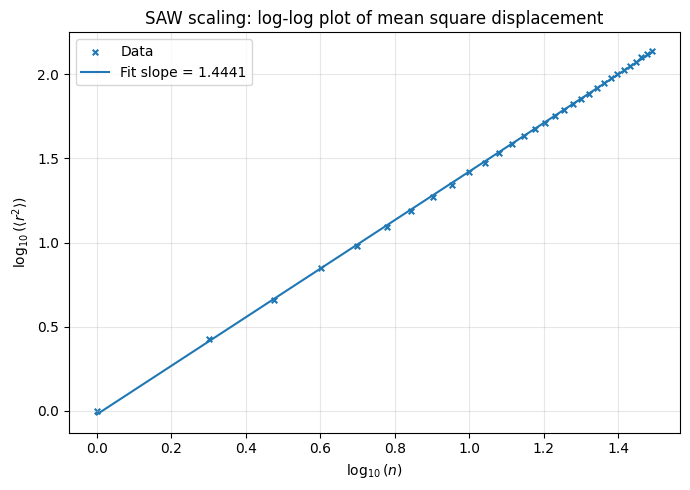

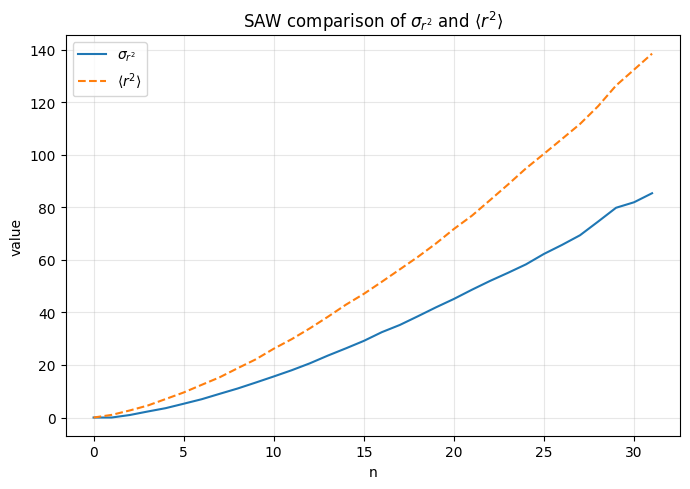

In [ ]:

import random;
from math import sqrt;
import numpy as np;
import matplotlib.pyplot as plt;


# Generate one self-avoiding walk
def generate_walk(Nsteps, lattice):
    dirs = ((1, 0), (-1, 0), (0, 1), (0, -1));
    x = np.zeros((Nsteps + 1, 2), dtype = int);
    x[0] = np.array([0, 0]);
    lattice[Nsteps, Nsteps] = 1;

    # first step can be any of 4 directions
    newdir = random.randint(0, 3);
    x[1] = dirs[newdir];
    lattice[x[1, 0] + Nsteps, x[1, 1] + Nsteps] = 1;
    revdir = newdir ^ 1;

    # subequent steps
    for n in range(2, Nsteps + 1):
        # choose one direction different from immediate reverse
        newdir = random.randint(0, 2);
        if newdir >= revdir:
            newdir += 1;

        x[n] = x[n - 1] + dirs[newdir];

        # if already occupied, walk dies at previous step
        if lattice[x[n, 0] + Nsteps, x[n, 1] + Nsteps] != 0:
            n -= 1;
            break;

        lattice[x[n, 0] + Nsteps, x[n, 1] + Nsteps] = 1;
        revdir = newdir ^ 1;

    else:
        n = Nsteps;

    # clear lattice
    for i in range(n + 1):
        lattice[x[i, 0] + Nsteps, x[i, 1] + Nsteps] = 0;

    return x[:n + 1], n;

# Running execution now
Nsteps = int(input("maximum number of steps: "));
Nwalks = int(input("number of walks: "));
cutoff = float(input("min fraction of surviving walks below which to cut off: "));
random.seed(580);
lattice = np.zeros((2 * Nsteps + 1, 2 * Nsteps + 1), dtype = int);
survivors = np.zeros(Nsteps + 1);
r2sum = np.zeros(Nsteps + 1);
r4sum = np.zeros(Nsteps + 1);

for _ in range(Nwalks):
  x, n = generate_walk(Nsteps, lattice);

  for i in range(n + 1):
    survivors[i] += 1;
    r2 = x[i, 0]**2 + x[i, 1]**2;
    r2sum[i] += r2;
    r4sum[i] += r2**2;

# cutoff in walk length where too few survive
for ncutoff in range(Nsteps + 1):
  if survivors[ncutoff] < cutoff * Nwalks:
    break;

nvals = np.arange(ncutoff);
r2avg = np.zeros(ncutoff);
r4avg = np.zeros(ncutoff);

for i in range(ncutoff):
  r2avg[i] = r2sum[i] / survivors[i];
  r4avg[i] = r4sum[i] / survivors[i];

sigma_r2 = np.sqrt(np.maximum(r4avg - r2avg**2, 0.0));

# log-log fit
logn = np.log10(nvals[1:]);
logr2 = np.log10(r2avg[1:]);

a, b = np.polyfit(logn, logr2, 1);
res = np.sum((a * logn + b - logr2)**2);
avx = np.mean(logn);
varx = np.sum((logn - avx)**2);
da = sqrt(res / (varx * (len(logn) - 2)));
nu = a / 2.0;
dnu = da / 2.0;
ratio = sigma_r2[1:] / r2avg[1:];

print("\nResults:");
print(f"cutoff step used                  = {ncutoff - 1}");
print(f"log10(<r^2>) = {a:.6f} * log10(n) + {b:.6f}");
print(f"slope uncertainty da             = {da:.6f}");
print(f"Estimated Flory exponent nu      = {nu:.6f}");
print(f"Estimated uncertainty dnu        = {dnu:.6f}");
print(f"Average sigma(r^2)/<r^2>         = {np.mean(ratio):.6f}");
print(f"Final sigma(r^2)/<r^2>           = {ratio[-1]:.6f}");

# plot <r^2> vs n on log-log axes
plt.figure(figsize = (7, 5));
plt.scatter(logn, logr2, s = 16, marker = "x", label = "Data");
plt.plot(logn, a * logn + b, label = f"Fit slope = {a:.4f}");
plt.xlabel(r"$\log_{10}(n)$");
plt.ylabel(r"$\log_{10}(\langle r^2\rangle)$");
plt.title("SAW scaling: log-log plot of mean square displacement");
plt.grid(True, alpha = 0.3);
plt.legend();
plt.tight_layout();
plt.show();

# plot fluctuation vs mean
plt.figure(figsize = (7, 5));
plt.plot(nvals, sigma_r2, label = r"$\sigma_{r^2}$");
plt.plot(nvals, r2avg, "--", label = r"$\langle r^2\rangle$");
plt.xlabel("n");
plt.ylabel("value");
plt.title(r"SAW comparison of $\sigma_{r^2}$ and $\langle r^2\rangle$");
plt.grid(True, alpha = 0.3);
plt.legend();
plt.tight_layout();
plt.show();

# EOF